# 05 - Características y validación por grupos

Acá junto los números que saqué de las ventanas de DroneRF. Primero miro algunas
características simples y después reviso si alcanzan para separar fondo y dron, modelo y
modo. La separación se hace por `group_id`, así que las ventanas de un mismo segmento no
pueden quedar repartidas entre entrenamiento y prueba.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

RAIZ = Path.cwd()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent

SRC = RAIZ / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from aps_drone_rf.estilo import COLORES, aplicar_estilo_matplotlib, color_clase, nombre_clase

aplicar_estilo_matplotlib()
pd.set_option("display.max_columns", 30)

ID_CORRIDA = "dronerf_demo_v2_final_n1024_hann_b20_seed42"
CARPETA_CORRIDA = RAIZ / "results" / "runs" / ID_CORRIDA
RUTA_FEATURES = CARPETA_CORRIDA / "features" / "features.csv"
RUTA_METRICAS = CARPETA_CORRIDA / "metricas" / "metricas_jerarquicas.json"
RUTA_MUESTRAS = CARPETA_CORRIDA / "metricas" / "metricas_demo_conservadora_final.json"

for ruta in [RUTA_FEATURES, RUTA_METRICAS, RUTA_MUESTRAS]:
    if not ruta.exists():
        raise FileNotFoundError(ruta)


## Datos que entran en la validación

La corrida usa 55 grupos para desarrollo y 12 para una evaluación separada. Los otros
12 grupos quedan afuera y se usan recién en la demostración. Cada grupo conserva sus dos
partes, L y H.


In [2]:
tabla_caracteristicas = pd.read_csv(RUTA_FEATURES)
metricas = json.loads(RUTA_METRICAS.read_text(encoding="utf-8-sig"))
metricas_muestras = json.loads(RUTA_MUESTRAS.read_text(encoding="utf-8-sig"))

grupos = tabla_caracteristicas[
    ["group_id", "partition", "activity", "model", "mode"]
].drop_duplicates()

print("Ventanas:", len(tabla_caracteristicas))
print("Grupos:", grupos["group_id"].nunique())
print("Partes por grupo:", tabla_caracteristicas.groupby("group_id")["part"].nunique().unique())
display(pd.crosstab(grupos["partition"], grupos["activity"], margins=True))


Ventanas: 13400
Grupos: 67
Partes por grupo: [2]


activity,dron,fondo,All
partition,,,
desarrollo,45,10,55
evaluacion,9,3,12
All,54,13,67


## Características simples

Para no hacer de cuenta que miles de ventanas son miles de mediciones independientes,
primero saco la mediana de cada característica dentro de cada grupo. Acá comparo RMS,
frecuencia dominante y centroide espectral.


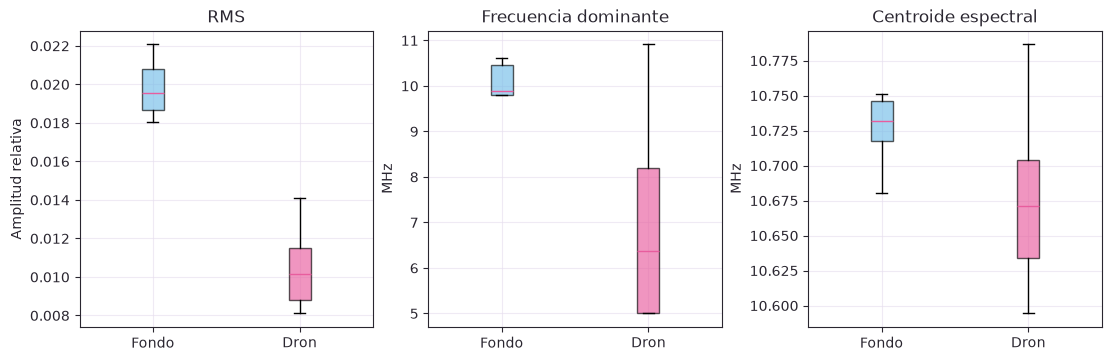

In [3]:
columnas = ["rms", "frecuencia_dominante_fft_hz", "centroide_espectral_hz"]
por_grupo = (
    tabla_caracteristicas.groupby(["group_id", "activity"])[columnas]
    .median()
    .reset_index()
)

fig, ejes = plt.subplots(1, 3, figsize=(11, 3.5), constrained_layout=True)
ajustes = [
    ("rms", "RMS", "Amplitud relativa", 1.0),
    ("frecuencia_dominante_fft_hz", "Frecuencia dominante", "MHz", 1e6),
    ("centroide_espectral_hz", "Centroide espectral", "MHz", 1e6),
]

for eje, (columna, titulo, unidad, escala) in zip(ejes, ajustes, strict=True):
    datos = [
        por_grupo.loc[por_grupo["activity"] == clase, columna].to_numpy() / escala
        for clase in ["fondo", "dron"]
    ]
    cajas = eje.boxplot(
        datos,
        tick_labels=[nombre_clase("fondo"), nombre_clase("dron")],
        patch_artist=True,
        showfliers=False,
    )
    for caja, clase in zip(cajas["boxes"], ["fondo", "dron"], strict=True):
        caja.set_facecolor(color_clase(clase))
        caja.set_alpha(0.65)
    eje.set_title(titulo)
    eje.set_ylabel(unidad)

ruta_figura = CARPETA_CORRIDA / "figuras" / "06_caracteristicas_por_grupo.png"
fig.savefig(ruta_figura, dpi=180, bbox_inches="tight")
plt.show()


## Validación sin mezclar registros

El modelo es una regresión logística lineal. El clasificador de referencia sirve para ver qué
pasaría sin aprender diferencias útiles. Las cifras de desarrollo son predicciones
obtenidas sobre grupos que quedaron fuera del ajuste; las de evaluación salen de grupos que no participaron en el ajuste.


,Referencia,Desarrollo,Evaluación reservada,Cobertura en evaluación
Nivel,,,,
Fondo / dron,0.500,1.000,1.000,1.000
Modelo,0.333,0.583,0.167,0.556
Modo Bebop,0.250,0.250,0.000,0.500
Modo AR,0.250,0.350,0.250,0.500


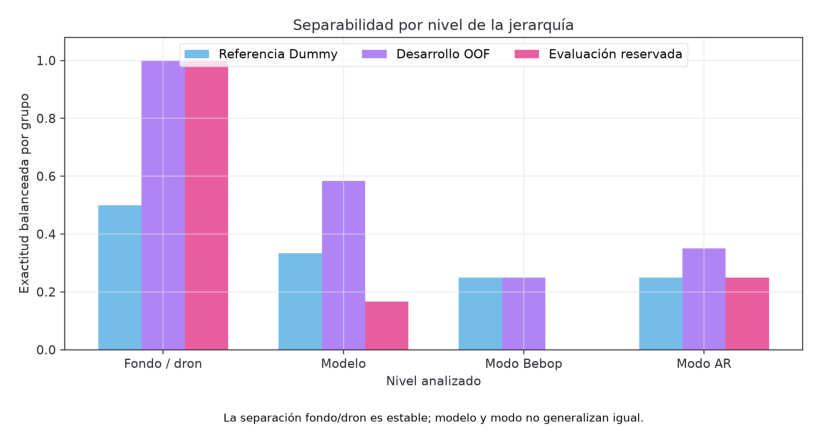

In [4]:
nombres = {
    "actividad": "Fondo / dron",
    "modelo": "Modelo",
    "modo_bebop": "Modo Bebop",
    "modo_ar": "Modo AR",
}

filas = []
for clave, nombre in nombres.items():
    filas.append(
        {
            "Nivel": nombre,
            "Referencia": metricas["dummy_oof"][clave]["balanced_accuracy"],
            "Desarrollo": metricas["oof_development"][clave]["balanced_accuracy"],
            "Evaluación reservada": metricas["reserved_evaluation"][clave]["balanced_accuracy"],
            "Cobertura en evaluación": metricas["reserved_evaluation"][clave]["coverage"],
        }
    )

tabla_validacion = pd.DataFrame(filas).set_index("Nivel")
display(tabla_validacion.round(3))

figura_validacion = plt.imread(CARPETA_CORRIDA / "figuras" / "03_resultados_jerarquia.png")
plt.figure(figsize=(11, 5.5))
plt.imshow(figura_validacion)
plt.axis("off")
plt.show()


## Muestras que no entraron al entrenamiento

Estas 12 muestras vienen de grupos separados desde el principio. El programa predice
primero y recién después consulta el catálogo con la respuesta esperada.


In [5]:
filas_muestras = []
for clave, nombre in [("activity", "Fondo / dron"), ("model", "Modelo"), ("mode", "Modo")]:
    valores = metricas_muestras[clave]
    filas_muestras.append(
        {
            "Nivel": nombre,
            "Exactitud balanceada": valores["balanced_accuracy"],
            "F1 macro": valores["f1_macro"],
            "Cobertura": valores["coverage"],
            "Grupos": valores["n_groups"],
        }
    )

tabla_muestras = pd.DataFrame(filas_muestras).set_index("Nivel")
display(tabla_muestras.round(3))
print("La separación fondo/dron se sostuvo. Modelo y modo quedan como resultados parciales.")


,Exactitud balanceada,F1 macro,Cobertura,Grupos
Nivel,,,,
Fondo / dron,1.0,1.0,1.0,12
Modelo,0.0,0.0,0.0,9
Modo,0.0,0.0,0.0,9


La separación fondo/dron se sostuvo. Modelo y modo quedan como resultados parciales.
